<a href="https://colab.research.google.com/github/annatsamoyra-prog/anna/blob/main/Upvotes_%CE%94%CE%9F%CE%9A%CE%99%CE%9C%CE%972.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import hvplot.pandas

from sklearn.model_selection import train_test_split

from sklearn import metrics

from sklearn.linear_model import LinearRegression

%matplotlib inline

In [3]:
df=pd.read_csv('https://raw.githubusercontent.com/annatsamoyra-prog/data_csv_forpractice/refs/heads/main/train_NIR5Yl1_HW.csv')

In [4]:
df.head()

,ID,Tag,Reputation,Answers,Username,Views,Upvotes
0,52664,a,3942.0,2.0,155623,7855.0,42.0
1,327662,a,26046.0,12.0,21781,55801.0,1175.0
2,468453,c,1358.0,4.0,56177,8067.0,60.0
3,96996,a,264.0,3.0,168793,27064.0,9.0
4,131465,c,4271.0,4.0,112223,13986.0,83.0


Ως κοινωνικός επιστήμονας που μελετά την επίδραση παραγόντων από τους παραπάνω, η γράφουσα αποφασίζει εδώ να βγάλει εκτός το ID και το TAG από τις μεταβλητές που θα ερευνήσουμε. Η δημιουργία του μοντέλου μου ξεκινά με την παραδοχή ότι αναζητά τη σχέση των εξης: Reputation, Answers, Username, και Views στα Upvotes.

In [5]:
X = df[["Reputation", "Answers","Username","Views"]]
y = df["Upvotes"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[-356.94986663   -5.70184233  396.13142871 2318.03361458 -442.19164345]


In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 11955918.295603516
RMSE: 3457.7331151497965
R² Score: 0.22105537559252175


In [8]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -314.9746095099887
Coefficients: [ 3.24720335e-02 -4.39907144e+01 -3.23101083e-04  2.01445153e-02]


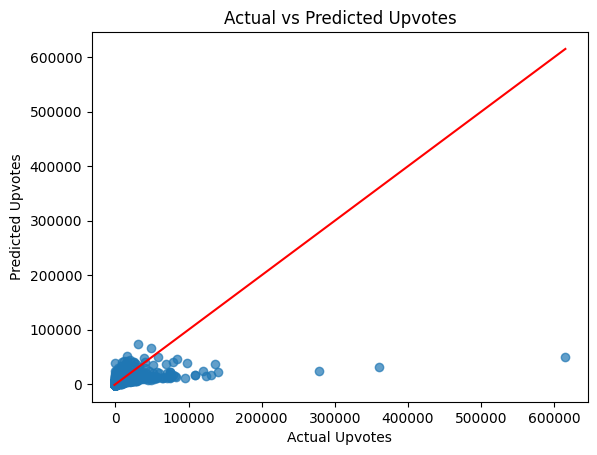

In [9]:
plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Upvotes")
plt.ylabel("Predicted Upvotes")
plt.title("Actual vs Predicted Upvotes")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.show()